<a href="https://colab.research.google.com/github/yumimint/c5c0a7724f4f38517ac5ffc86e129f4e/blob/main/picloader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [131]:
!pip install bitstring
from bitstring import BitStream


In [ ]:
from collections import deque, namedtuple
from PIL import Image
import numpy as np
import requests
from typing import Callable


In [132]:
def ldecode(bs: BitStream) -> int:
    bits = 1
    # 0が出るまで1をカウントする
    while bs.read("bool"):
        bits += 1

    # 指定したビット数分を整数として読み込む
    x = bs.read(f"uint:{bits}")
    x += (1 << bits) - 1
    return x


def read_until(bs: BitStream, term: bytes):
    buf = b''
    while True:
        b = bs.read("bytes:1")
        if b == term:
            break
        buf += b
    return buf


def read_header(bs: BitStream):
    # 1. Magicの確認
    if bs.read("bytes:3") != b"PIC":
        raise ValueError("Magic not match.")

    # # 2. コメントセクション (0x1aまで)
    comment = read_until(bs, b"\x1a")

    # # 3. ダミー/真の終端 (0x00まで)
    dummy = read_until(bs, b"\x00")

    res, mode, bpp, width, height = bs.readlist("2*uint:8, 3*uint:16")

    HD = namedtuple(
        "PIC_Header", "comment dummy reserve mode bpp width height")
    return HD(comment, dummy, res, mode, bpp, width, height)


class ColorCache:
    class Node:
        def __init__(self):
            self.color = 0
            self.next = self
            self.prev = self

        def cut(self):
            self.next.prev = self.prev
            self.prev.next = self.next
            # self.next = self
            # self.prev = self
            return self

        def insert(self, place):
            place.prev.next = self
            self.prev = place.prev
            place.prev = self
            self.next = place
            return self

    def __init__(self):
        """色キャッシュの初期化"""
        self.table = [self.Node() for i in range(128)]
        self.color_p = self.table[0]  # 最新色を指す
        for i, p in enumerate(self.table):
            p.color = 0
            p.prev = self.table[(i + 1) & 127]
            p.next = self.table[i - 1]

    def get(self, idx: int):
        """キャッシュから色を取り出しその色が最新になるように更新する"""
        p = self.table[idx]
        if p != self.color_p:
            self.color_p = p.cut().insert(self.color_p)
        return p.color

    def put(self, color):
        """新しい色をキャッシュに登録"""
        self.color_p = self.color_p.prev
        self.color_p.color = color
        return color

    def find(self, color) -> int:
        for i, p in enumerate(self.table):
            if p.color == color:
                self.get(i)
                return i
        return -1


def chain(bs: BitStream, pix: np.ndarray, flg: np.ndarray, i: int, c: int):
    y, x = np.unravel_index(i, pix.shape)

    while True:
        lr = bs.read("uint:2")
        if lr == 0:
            if not bs.read("bool"):
                break
            else:
                d = 2 if bs.read("bool") else -2
        elif lr == 1:
            d = -1
        elif lr == 2:
            d = 0
        elif lr == 3:
            d = 1
        y, x = y + 1, x + d
        try:
            pix[y][x] = c
            flg[y][x] = True
        except IndexError:
            pass
            # 壊れデータ対策


def decode(bs: BitStream, pix: np.ndarray, read_color: Callable):
    flg = np.zeros(pix.shape, dtype=bool)

    i = -1  # (-1, 0)からスタート
    c = 0   # 色は0から

    imax = pix.shape[0] * pix.shape[1]
    while i < imax:
        L = ldecode(bs)  # 長さ
        n = min(imax - i - 1, L - 1)
        while n:
            n -= 1
            i += 1
            if flg.flat[i]:
                # 連鎖点上を通過した時は、現在の色を変更
                c = pix.flat[i]
                continue
            pix.flat[i] = c

        i += 1
        if i >= imax:
            break

        c = read_color()
        pix.flat[i] = c

        if bs.read("bool"):
            chain(bs, pix, flg, i, c)


def get_color_function(bits: int, bs: BitStream) -> Callable:
    if bits in [12, 15, 16, 24]:
        cache = ColorCache()
        def read_with_cache():
            if bs.read("bool"):
                c = cache.get(bs.read("uint:7"))
            else:
                c = cache.put(bs.read(f"uint:{bits}"))
            return c

        return read_with_cache

    def read_direct():
        c = bs.read(f"uint:{bits}")
        return c

    return read_direct


def decode_pic(f):
    bs = BitStream(f)
    hd = read_header(bs)
    dtype = np.uint8 if hd.bpp <= 8 else (
        np.uint16 if hd.bpp <= 16 else np.uint32)
    read_color = get_color_function(hd.bpp, bs)
    pixel = np.zeros((hd.height, hd.width), dtype=dtype)
    decode(bs, pixel, read_color)
    return pixel


def split_color_15(color):
    g5 = (color >> 10) & 0x1F
    r5 = (color >> 5) & 0x1F
    b5 = color & 0x1F

    # スケーリング (ビットをずらして結合)
    # 5bitを3bit左シフトし、空いた下位3bitに上位3bitをコピーする
    # 例: 11111 -> 11111000 + 00000111 = 11111111 (255)
    r8 = (r5 << 3) | (r5 >> 2)
    g8 = (g5 << 3) | (g5 >> 2)
    b8 = (b5 << 3) | (b5 >> 2)

    return r8, g8, b8

def x68_15_to_rgb(color):
    r, g, b = split_color_15(color)
    rgb_array = np.dstack([r, g, b]).astype(np.uint8)
    return Image.fromarray(rgb_array)

In [133]:
req = requests.get("https://github.com/yumimint/c5c0a7724f4f38517ac5ffc86e129f4e/raw/refs/heads/main/sample.pic")


In [134]:
read_header(BitStream(req.content))

PIC_Header(comment=b'', dummy=b'', reserve=0, mode=0, bpp=15, width=512, height=512)

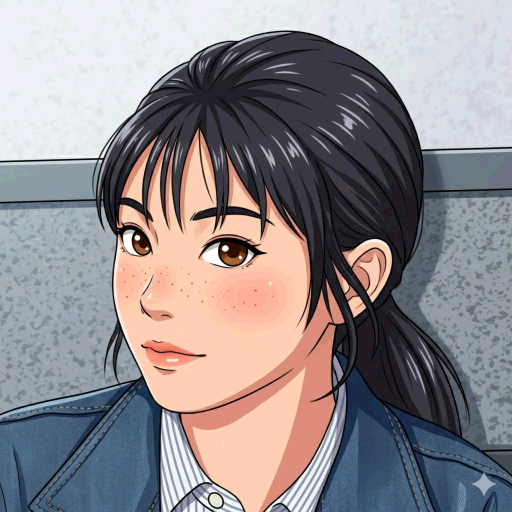

In [135]:
im = decode_pic(BitStream(req.content))
x68_15_to_rgb(im)
